# Turbofan Engine Analysis — Understanding the Data Before We Model

**Author:** Emmy  
**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Simulation (FD001 subset)  
**Goal of this notebook:** get to know the data well enough to prepare good, fair training data for the two models we are comparing later — a **TCN** (which predicts the next sensor reading) and an **Autoencoder** (which tries to reconstruct a window of normal engine behaviour).

Before training any model, it's worth spending time just *looking* at the data. This notebook does not build or train a model — it answers practical questions we need answered first, such as:

- How much data do we actually have, and is it clean?
- Which sensors are actually useful, and which ones barely change (and can be dropped)?
- What does a "healthy" engine look like compared to a "degrading" one?
- Is a 30-cycle window a reasonable size to use?
- Do the sensors need to be rescaled before we feed them into a model?

Every section below ends with a short takeaway that feeds directly into how we build the training data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)


## 1. Loading the data

We use the **FD001** subset of the C-MAPSS dataset, as agreed for the group project. FD001 is the
simplest subset: all engines fly under **one operating condition** and develop **one type of fault**.
That makes it a fair, controlled setting to compare the TCN and the Autoencoder — any difference we
see later should come from the *modelling approach*, not from extra complexity in the data.

Each row in `train_FD001.txt` / `test_FD001.txt` is one engine, on one flight cycle. The columns are:

- `unit_number` — which engine (1, 2, 3, ...)
- `time_in_cycles` — the flight cycle number for that engine (starts at 1)
- `op_setting_1..3` — three operating settings (altitude, speed, throttle-like settings)
- `sensor_1..sensor_21` — 21 sensor readings (temperatures, pressures, speeds, etc.)

The **training set** contains full run-to-failure histories (each engine flies until it fails).
The **test set** is cut off at some earlier cycle, and the true remaining life at that cutoff is
given separately in `RUL_FD001.txt` — that's our answer key for evaluating the models later.


In [2]:
index_names = ["unit_number", "time_in_cycles"]
setting_names = ["op_setting_1", "op_setting_2", "op_setting_3"]
sensor_names = [f"sensor_{i}" for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

DATA_DIR = "../data/raw"

train = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None, names=col_names)
test = pd.read_csv(f"{DATA_DIR}/test_FD001.txt", sep=r"\s+", header=None, names=col_names)
rul_test = pd.read_csv(f"{DATA_DIR}/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])

print("train shape:", train.shape)
print("test shape: ", test.shape)
print("rul_test shape:", rul_test.shape)
print()
print("Number of engines in train:", train["unit_number"].nunique())
print("Number of engines in test: ", test["unit_number"].nunique())
train.head()


train shape: (20631, 26)
test shape:  (13096, 26)
rul_test shape: (100, 1)

Number of engines in train: 100
Number of engines in test:  100


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Notice already that the sensors are on very different scales — some are around 1–2 (like
`op_setting_1`), others are in the hundreds or thousands (like `sensor_9`, which is close to 9000).
We'll come back to this later, because it matters a lot once we start training a model.


In [3]:
train[sensor_names].describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
sensor_1,518.670000,0.000000e+00,518.6700,518.6700
sensor_2,642.680934,5.000533e-01,641.2100,644.5300
sensor_3,1590.523119,6.131150e+00,1571.0400,1616.9100
sensor_4,1408.933782,9.000605e+00,1382.2500,1441.4900
sensor_5,14.620000,5.329200e-15,14.6200,14.6200
sensor_6,21.609803,1.388985e-03,21.6000,21.6100
sensor_7,553.367711,8.850923e-01,549.8500,556.0600
sensor_8,2388.096652,7.098548e-02,2387.9000,2388.5600
sensor_9,9065.242941,2.208288e+01,9021.7300,9244.5900
sensor_10,1.300000,0.000000e+00,1.3000,1.3000


## 2. How long do engines run before failing?

In the training set, every engine flies until it breaks down — so the **last cycle number for each
engine is that engine's total lifetime**. Knowing how lifetimes are distributed matters a lot for
later steps: it tells us how much "healthy" data we'll have per engine, and whether a 30-cycle window
is a sensible size to use.


Engine lifetimes (in flight cycles):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64


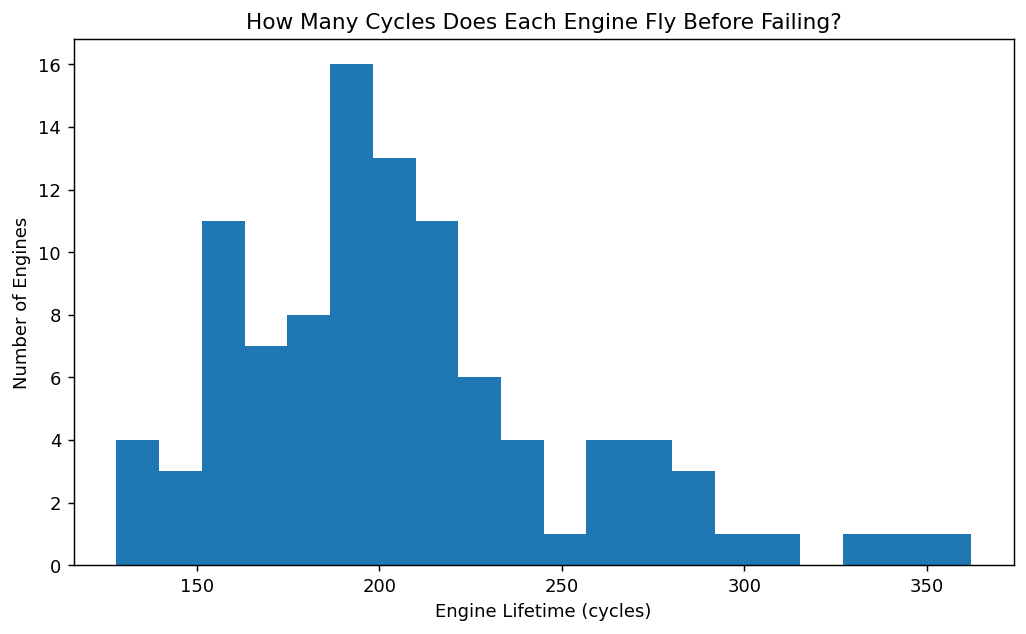

In [4]:
cycles_per_engine = train.groupby("unit_number")["time_in_cycles"].max()
print("Engine lifetimes (in flight cycles):")
print(cycles_per_engine.describe())

plt.figure(figsize=(8, 5))
plt.hist(cycles_per_engine, bins=20)
plt.title("How Many Cycles Does Each Engine Fly Before Failing?")
plt.xlabel("Engine Lifetime (cycles)")
plt.ylabel("Number of Engines")
plt.tight_layout()
plt.show()


**Takeaway:** engines live anywhere from about 130 to over 360 cycles, with a typical engine lasting
roughly 200 cycles. That's a wide spread — some engines simply don't give us much data. This is
important later when we decide how much of each engine's life counts as "healthy."


## 3. Is the data clean?

A quick but important check: are there any missing readings? Simulated datasets like this one
are usually clean, but it's a habit worth keeping for any real dataset.


In [5]:
missing_train = train.isna().sum().sum()
missing_test = test.isna().sum().sum()
print(f"Missing values in train: {missing_train}")
print(f"Missing values in test:  {missing_test}")


Missing values in train: 0
Missing values in test:  0


**Takeaway:** no missing values. We can move on without needing to fill in or drop any gaps.


## 4. Confirming FD001 really is "one operating condition"

The project brief for FD001 says all engines fly under a single operating condition. Let's actually
check that in the data rather than just assuming it, by looking at the three operating settings.


In [6]:
train[setting_names].describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
op_setting_1,-0.000009,0.002187,-0.0087,0.0087
op_setting_2,0.000002,0.000293,-0.0006,0.0006
op_setting_3,100.000000,0.000000,100.0000,100.0000


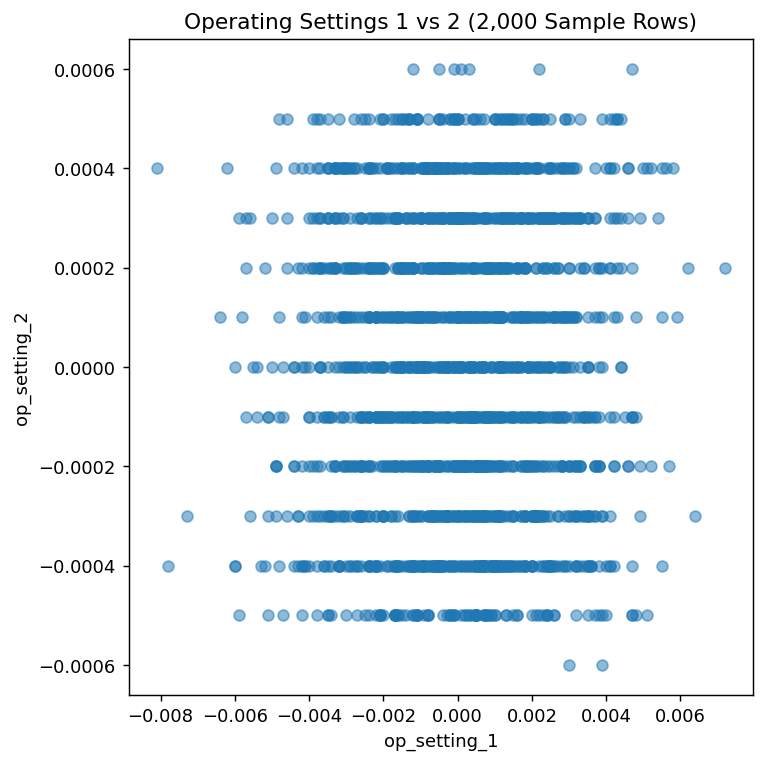

In [7]:
sample = train.sample(2000, random_state=0)

plt.figure(figsize=(6, 6))
plt.scatter(sample["op_setting_1"], sample["op_setting_2"], alpha=0.5)
plt.title("Operating Settings 1 vs 2 (2,000 Sample Rows)")
plt.xlabel("op_setting_1")
plt.ylabel("op_setting_2")
plt.tight_layout()
plt.show()


**Takeaway:** the settings barely move (tiny standard deviations) and form one tight cluster in the
scatter plot, apart from small sensor noise. This confirms FD001 really is a single-operating-condition
subset — good, because it means we don't need to normalize per operating regime, which keeps the
comparison between TCN and Autoencoder simpler and fairer.


## 5. Which sensors are actually useful?

Some sensors never really change — they were probably saturated instruments or settings that don't
respond to engine wear in this dataset. Including them wouldn't help either model, and could even hurt
the Autoencoder in particular (a constant input adds no information but does add noise to the window
it has to reconstruct). The simplest and most beginner-friendly way to spot a "dead" sensor is to count
**how many different values it ever takes** across the whole training set — a genuinely useful sensor
should show a wide spread of readings as the engine ages.


In [8]:
n_unique = train[sensor_names].nunique().sort_values()
n_unique


sensor_1        1
sensor_5        1
sensor_16       1
sensor_10       1
sensor_19       1
sensor_18       1
sensor_6        2
sensor_17      13
sensor_8       53
sensor_13      56
sensor_20     120
sensor_11     159
sensor_2      310
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

In [9]:
# A sensor with only a handful of distinct readings across ~20,000 rows carries basically no signal
drop_sensors = n_unique[n_unique <= 2].index.tolist()
keep_sensors = [s for s in sensor_names if s not in drop_sensors]

print(f"Sensors to drop ({len(drop_sensors)}): {drop_sensors}")
print(f"Sensors to keep ({len(keep_sensors)}): {keep_sensors}")


Sensors to drop (7): ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_6']
Sensors to keep (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


**Takeaway:** 7 sensors barely change at all and can be dropped before training — this matches what
the group already agreed on ("drop the ~7 constant sensors"). That leaves **14 informative sensors**
for both the TCN and the Autoencoder to work with.


## 6. Which sensors react most to engine age?

Now that we've dropped the flat sensors, let's see which of the remaining 14 sensors change *the most*
as an engine gets older. We do this with a simple correlation between each sensor's reading and the
cycle number. A correlation close to +1 or -1 means "this sensor moves consistently as the engine
ages" — exactly the kind of signal both models will be trying to pick up on.


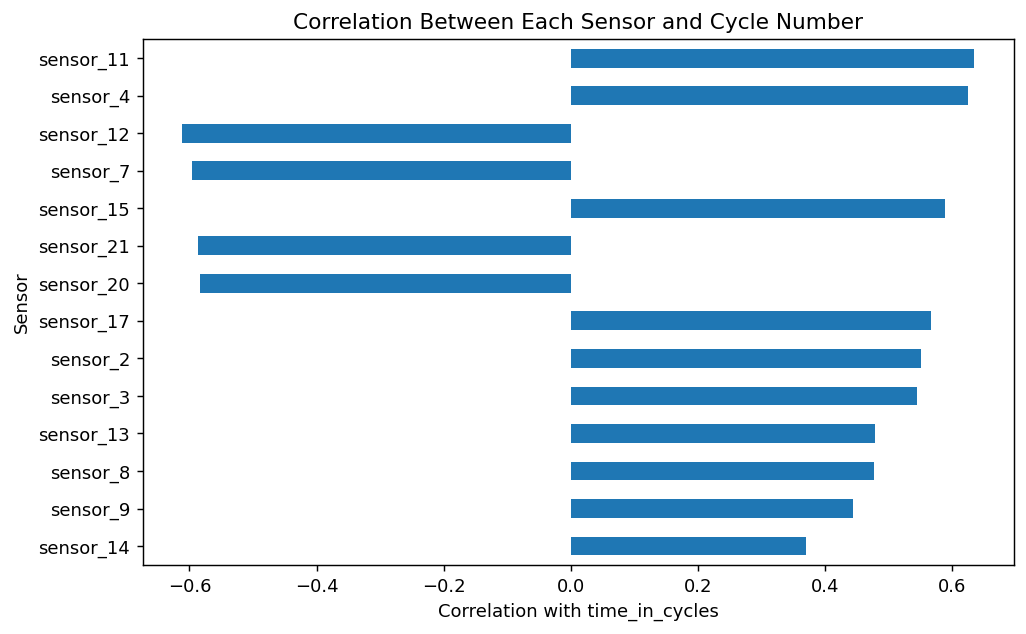

In [10]:
corr_with_cycle = (
    train[keep_sensors + ["time_in_cycles"]]
    .corr()["time_in_cycles"]
    .drop("time_in_cycles")
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(8, 5))
corr_with_cycle.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Correlation Between Each Sensor and Cycle Number")
plt.xlabel("Correlation with time_in_cycles")
plt.ylabel("Sensor")
plt.tight_layout()
plt.show()


**Takeaway:** sensors like `sensor_11`, `sensor_4` and `sensor_12` show the strongest relationship
with engine age. These are good candidates to sanity-check visually next, and they're the sensors most
likely to drive both models' warning signals.


## 7. What does degradation actually look like?

Numbers are useful, but it helps a lot to just *see* a few engines age. Below we plot the
strongest-correlated sensor (`sensor_11`) over time for a handful of individual engines — one short-lived,
one typical, one long-lived — so we can visually confirm there's a real trend, not just noise.


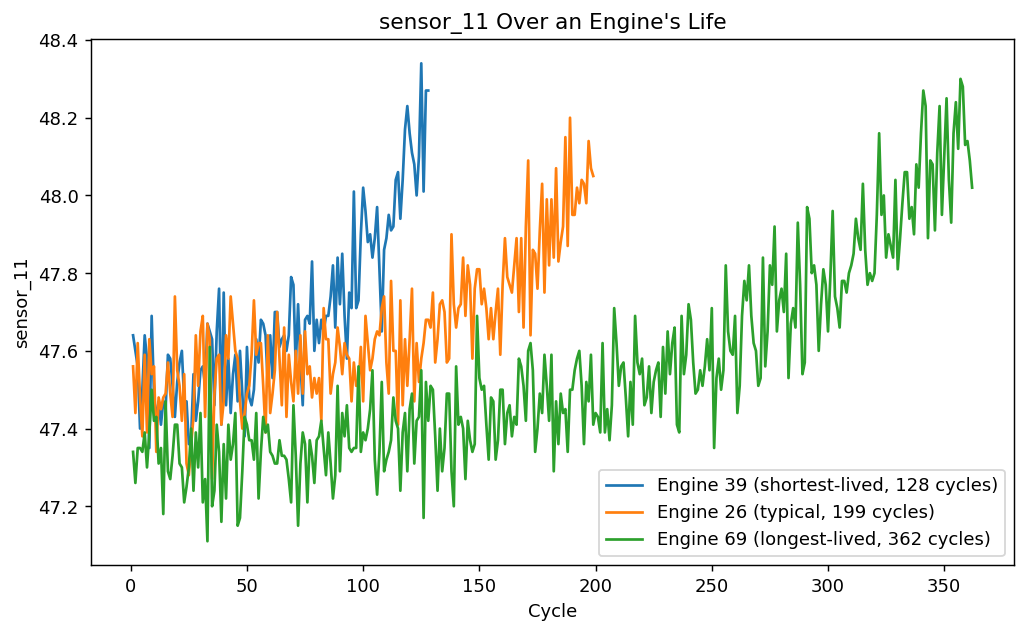

In [11]:
example_units = [
    cycles_per_engine.idxmin(),
    cycles_per_engine.index[(cycles_per_engine - cycles_per_engine.median()).abs().argsort().iloc[0]],
    cycles_per_engine.idxmax(),
]
labels = ["shortest-lived", "typical", "longest-lived"]
sensor_to_plot = corr_with_cycle.index[0]

plt.figure(figsize=(8, 5))
for unit, label in zip(example_units, labels):
    engine_data = train[train["unit_number"] == unit]
    plt.plot(engine_data["time_in_cycles"], engine_data[sensor_to_plot],
             label=f"Engine {unit} ({label}, {cycles_per_engine[unit]} cycles)")
plt.title(f"{sensor_to_plot} Over an Engine's Life")
plt.xlabel("Cycle")
plt.ylabel(sensor_to_plot)
plt.legend()
plt.tight_layout()
plt.show()


**Takeaway:** all three engines start in a similar range early on, then drift in the same direction as
they approach failure — the drift just happens sooner for the short-lived engine. This is exactly the
pattern the TCN and Autoencoder are designed to catch: early on, behaviour is stable and predictable;
later, it isn't.


## 8. Do the sensors overlap with each other?

It's also worth checking whether some of our 14 kept sensors are basically measuring the same thing.
Highly overlapping (redundant) sensors aren't wrong to include, but it's good to know about — it
explains why a model might treat several sensors as "one shared signal" rather than 14 independent
ones.


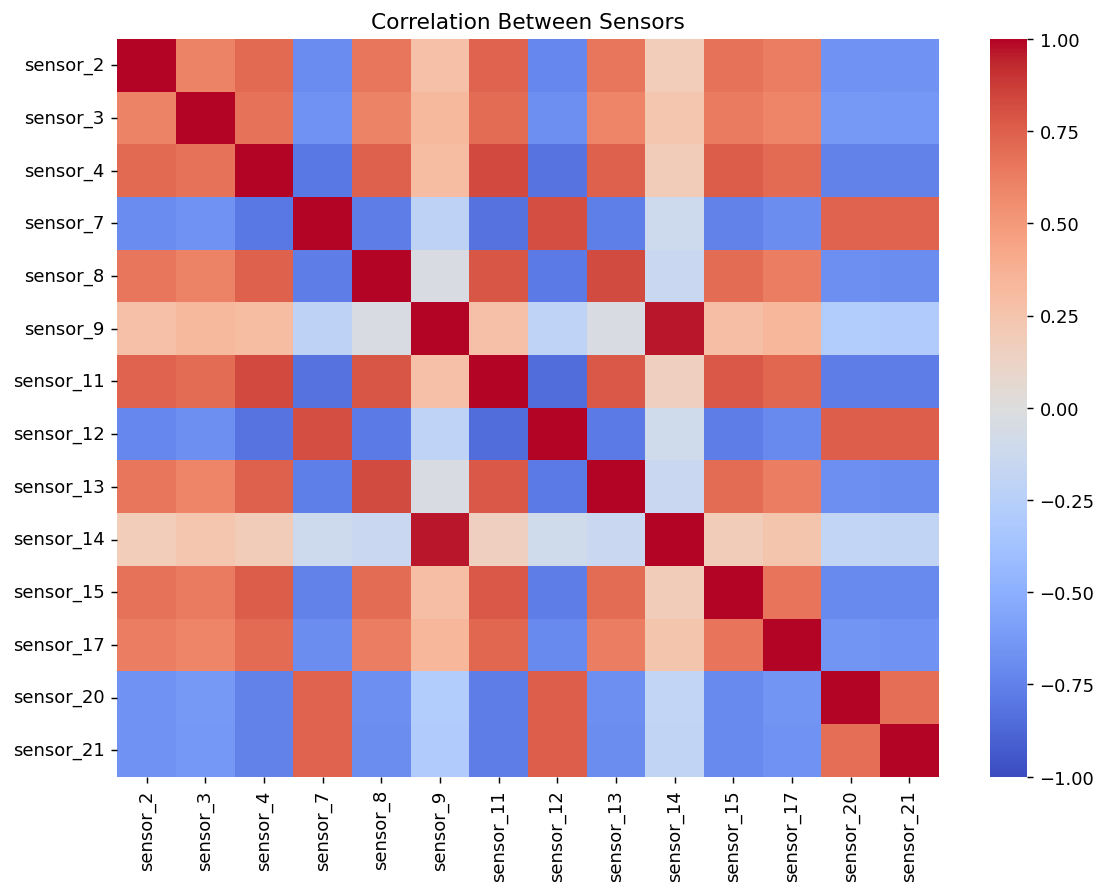

In [12]:
import seaborn as sns

corr_matrix = train[keep_sensors].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, annot=False)
plt.title("Correlation Between Sensors")
plt.tight_layout()
plt.show()


**Takeaway:** a few clusters of sensors move together very strongly (dark blue or dark red squares off
the diagonal) — for example the temperature-related sensors tend to rise together, and so do the
speed-related ones. Nothing here is a reason to drop more sensors, but it explains why the models may
end up relying on a smaller number of *independent* signals in practice.


## 9. Defining "healthy" — the first 30% of life

Both models need labeled examples of *healthy* behaviour to learn from. As agreed, we're defining
"healthy" as the first 30% of each engine's life, on the assumption that engines start in good
condition and only begin drifting later. Let's check whether that assumption actually holds up in the
data, using our top sensor again.


Drift rate in the first 30% of life:  0.1159 per unit of life fraction
Drift rate in the remaining 70%:      0.9995 per unit of life fraction
-> the sensor drifts about 8.6x faster after the 30% mark


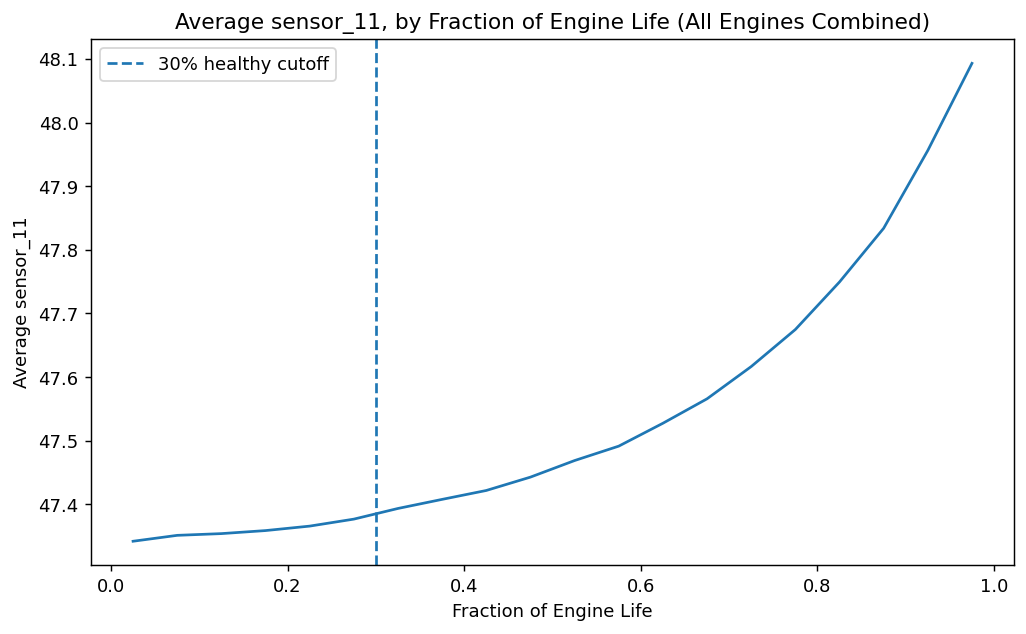

In [13]:
train = train.merge(cycles_per_engine.rename("life"), on="unit_number")
train["life_fraction"] = train["time_in_cycles"] / train["life"]
train["is_healthy"] = train["life_fraction"] <= 0.30

# Average sensor reading at each 5%-of-life bucket, across all engines
bins = np.arange(0, 1.05, 0.05)
train["life_bucket"] = pd.cut(train["life_fraction"], bins)
trend = train.groupby("life_bucket", observed=True)[sensor_to_plot].mean()

# Compare how fast the sensor drifts before vs after the 30% cutoff
early = trend[trend.index.map(lambda b: b.right <= 0.30)]
late = trend[trend.index.map(lambda b: b.left >= 0.30)]
early_slope = (early.iloc[-1] - early.iloc[0]) / 0.30
late_slope = (late.iloc[-1] - late.iloc[0]) / 0.70
print(f"Drift rate in the first 30% of life:  {early_slope:.4f} per unit of life fraction")
print(f"Drift rate in the remaining 70%:      {late_slope:.4f} per unit of life fraction")
print(f"-> the sensor drifts about {late_slope / early_slope:.1f}x faster after the 30% mark")

x = [interval.mid for interval in trend.index]

plt.figure(figsize=(8, 5))
plt.plot(x, trend.values)
plt.axvline(0.30, linestyle="--", label="30% healthy cutoff")
plt.title(f"Average {sensor_to_plot}, by Fraction of Engine Life (All Engines Combined)")
plt.xlabel("Fraction of Engine Life")
plt.ylabel(f"Average {sensor_to_plot}")
plt.legend()
plt.tight_layout()
plt.show()


**Takeaway:** the sensor does drift a little even early on, but the drift rate is much steeper after
the 30% mark than before it (see the printed ratio above). In other words, engines are relatively
stable early in life and change much faster later — so calling the first 30% "healthy" is a reasonable,
if slightly conservative, choice for both models to train on.


## 10. Is a 30-cycle window realistic?

Both models will look at windows of 30 consecutive cycles. That only works if each engine actually has
at least 30 healthy cycles to build a window from — otherwise we'd have engines contributing zero
training examples. Let's check.


Shortest healthy period across all engines: 38 cycles
Engines with at least 30 healthy cycles: 100 / 100 (100%)


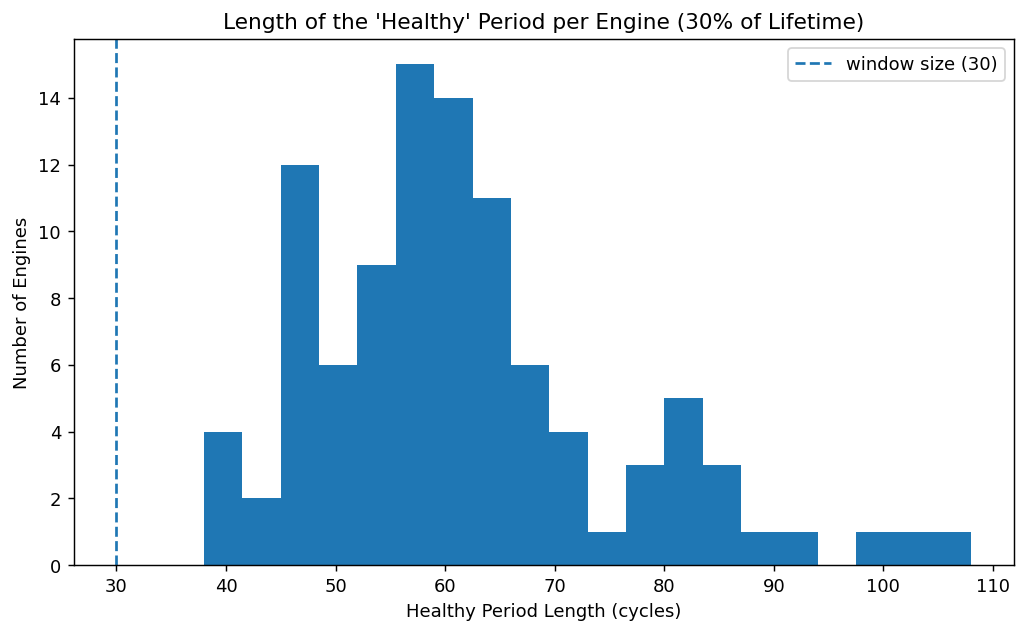

In [14]:
healthy_length = (cycles_per_engine * 0.30).astype(int)
window_size = 30
engines_with_enough_data = (healthy_length >= window_size).sum()
total_engines = len(cycles_per_engine)

print(f"Shortest healthy period across all engines: {healthy_length.min()} cycles")
print(f"Engines with at least {window_size} healthy cycles: "
      f"{engines_with_enough_data} / {total_engines} "
      f"({engines_with_enough_data / total_engines:.0%})")

plt.figure(figsize=(8, 5))
plt.hist(healthy_length, bins=20)
plt.axvline(window_size, linestyle="--", label="window size (30)")
plt.title("Length of the 'Healthy' Period per Engine (30% of Lifetime)")
plt.xlabel("Healthy Period Length (cycles)")
plt.ylabel("Number of Engines")
plt.legend()
plt.tight_layout()
plt.show()


**Takeaway:** every engine's healthy period is comfortably longer than 30 cycles, even the shortest-lived
one. A 30-cycle window is a safe choice — we won't lose any engines for having too little healthy data.


## 11. The test set's answer key: Remaining Useful Life

Unlike the training engines (which we watch all the way to failure), each test engine's data is cut
off partway through its life. `RUL_FD001.txt` tells us exactly how many cycles were left at that
cutoff point for each of the 100 test engines — this is what we'll compare our models' warning signals
against later.


count    100.00000
mean      75.52000
std       41.76497
min        7.00000
25%       32.75000
50%       86.00000
75%      112.25000
max      145.00000
Name: RUL, dtype: float64


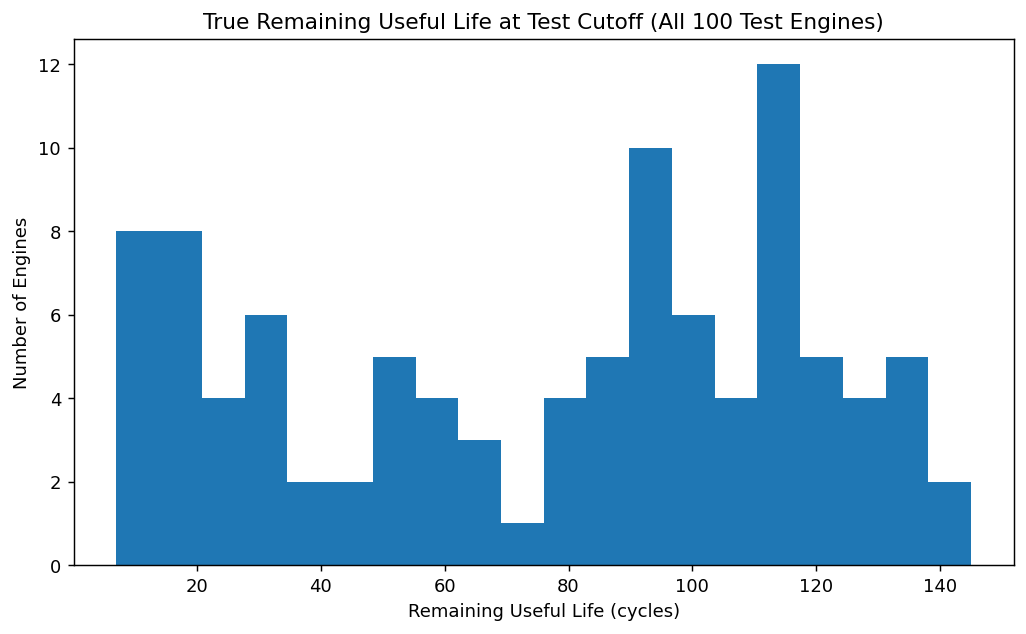

In [15]:
print(rul_test["RUL"].describe())

plt.figure(figsize=(8, 5))
plt.hist(rul_test["RUL"], bins=20)
plt.title("True Remaining Useful Life at Test Cutoff (All 100 Test Engines)")
plt.xlabel("Remaining Useful Life (cycles)")
plt.ylabel("Number of Engines")
plt.tight_layout()
plt.show()


**Takeaway:** test engines were cut off anywhere from right before failure to well over 100 cycles
early. This spread is actually useful for evaluation — it lets us check whether a model's warning
signal rises smoothly as true RUL drops, across a wide range of "how close to failure" situations.


## 12. One last thing: the sensors need to be rescaled

We noticed this back in section 1 — let's confirm it properly now that we know which 14 sensors we're
actually keeping. Both the TCN and the Autoencoder work with the raw numbers we feed them, and if one
sensor ranges in the thousands while another ranges under 10, the larger sensor will dominate the
model's error signal for no good reason.


In [16]:
train[keep_sensors].agg(["min", "max"]).T.assign(
    range=lambda d: d["max"] - d["min"]
).sort_values("range")


,min,max,range
sensor_15,8.3249,8.5848,0.2599
sensor_8,2387.9000,2388.5600,0.6600
sensor_13,2387.8800,2388.5600,0.6800
sensor_21,22.8942,23.6184,0.7242
sensor_20,38.1400,39.4300,1.2900
sensor_11,46.8500,48.5300,1.6800
sensor_2,641.2100,644.5300,3.3200
sensor_12,518.6900,523.3800,4.6900
sensor_7,549.8500,556.0600,6.2100
sensor_17,388.0000,400.0000,12.0000


**Takeaway:** ranges vary from single digits to several thousand. Both models must scale every sensor
(for example with min-max or standard scaling) **fit only on the healthy training data**, then apply
that same scaling to everything else. This is exactly the kind of detail that has to be identical
between the TCN and Autoencoder notebooks for the comparison to be fair.


## Summary — what this means for building our training data

Putting it all together, here's what this notebook tells us to actually do when preparing training
data for both the TCN and the Autoencoder:

1. **Use FD001 only** (`train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt`) — confirmed to be a single
   operating condition, so no extra normalization for flight regime is needed.
2. **Drop these 7 near-constant sensors**: `sensor_1, sensor_5, sensor_6, sensor_10, sensor_16,
   sensor_18, sensor_19`. Keep the other 14 — they all show a real, visible relationship with engine
   age.
3. **Use a 30-cycle window.** Every engine's healthy period is long enough to support it, so we won't
   lose engines from the training set.
4. **Define "healthy" as the first 30% of each engine's life.** The data backs this up — sensor
   averages stay flat until roughly that point, then start climbing.
5. **Scale every sensor** (e.g. min-max or z-score), fitting the scaler on the *healthy training data
   only*, then reusing it everywhere else. This step must be done identically for both models.

None of this compares the TCN and Autoencoder yet — that's the job of the next two notebooks. This
notebook's job was just to make sure both of them start from the same, well-understood, fairly
prepared data.
